In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## 特征匹配

### Brute-Force 蛮力匹配

(<Axes: title={'center': 'matches'}>,
 Text(0.5, 1.0, 'matches'),
 (-0.5, 1345.5, 1705.5, -0.5))

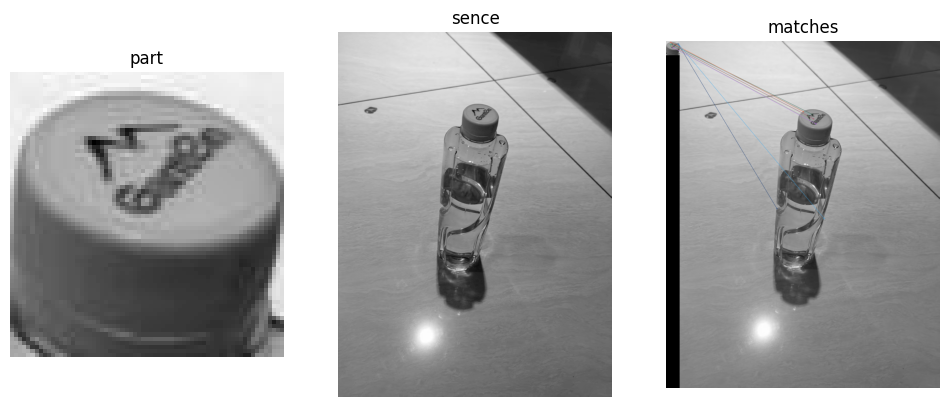

In [7]:
img1 = cv2.imread('./assets/p.jpg', 0)
img2 = cv2.imread('./assets/1.jpg', 0)

sift = cv2.xfeatures2d.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher(crossCheck=True)

# 1 对 1 匹配
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

img3 = cv2.drawMatches(img1, kp1, img2, kp2, matches[:10], None, flags = 2)

plt.figure(figsize=(12, 12))
plt.subplot(231), plt.imshow(img1, 'gray'), plt.title("part"), plt.axis('off')
plt.subplot(232), plt.imshow(img2, 'gray'), plt.title("sence"), plt.axis('off')
plt.subplot(233), plt.imshow(img3, 'gray'), plt.title("matches"), plt.axis('off')

### k 对 最佳匹配

(<Axes: title={'center': 'matches'}>,
 Text(0.5, 1.0, 'matches'),
 (-0.5, 1345.5, 1705.5, -0.5))

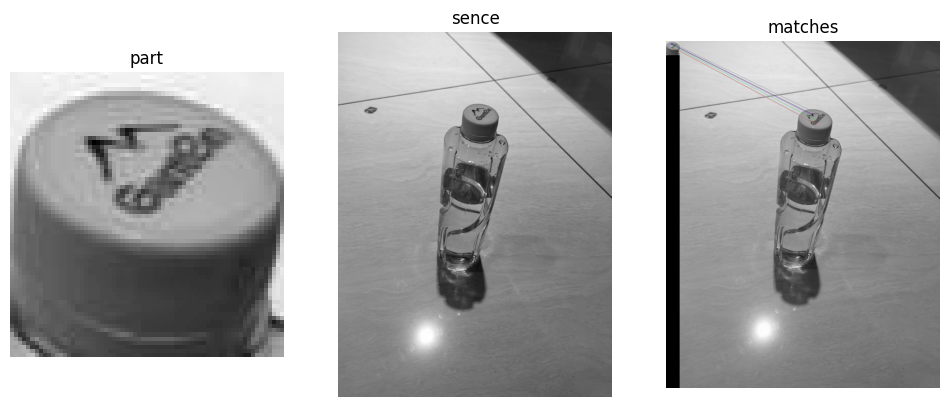

In [ ]:
img1 = cv2.imread('./assets/p.jpg', 0)
img2 = cv2.imread('./assets/1.jpg', 0)

sift = cv2.xfeatures2d.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# FlannBasedMatcher 比 BFMatcher 更快，树剪枝优化
# bf = cv2.BFMatcher()
bf = cv2.FlannBasedMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
# 逐个解包每个元素
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good, None, flags = 2)

plt.figure(figsize=(12, 12))
plt.subplot(231), plt.imshow(img1, 'gray'), plt.title("part"), plt.axis('off')
plt.subplot(232), plt.imshow(img2, 'gray'), plt.title("sence"), plt.axis('off')
plt.subplot(233), plt.imshow(img3, 'gray'), plt.title("matches"), plt.axis('off')

### RANSAC 算法

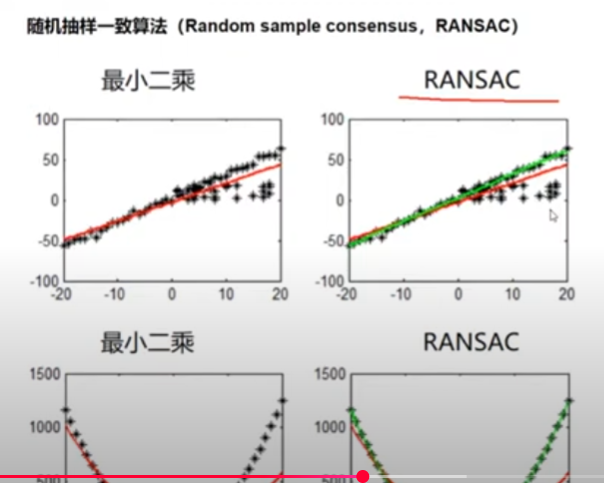

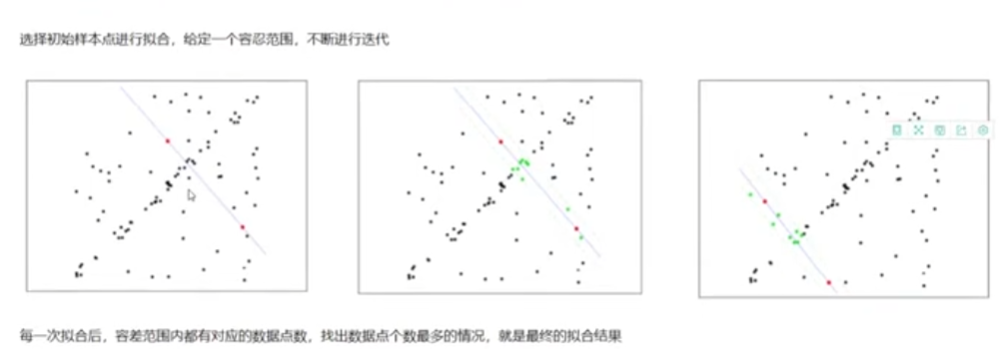

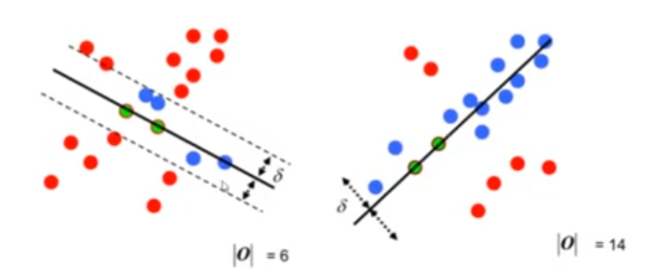